# Guía 1 - Ejercicio 1: Flujos unidimensionales

Para cada ecuación diferencial:
1. Graficar el campo vectorial
2. Encontrar puntos fijos y clasificar su estabilidad
3. Graficar trayectorias x(t) para distintas condiciones iniciales
4. Graficar el retrato de fases (x vs dx/dt)
5. Intentar solución analítica

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.grid': True,
    'grid.alpha': 0.3
})

In [2]:
def plot_vector_field_and_trajectories(f, name, x_range=(-3, 3), n_points=200, t_span=(0, 10),
                                       x0_values=None, fixed_points=None, clip_at=None,
                                       runaway_bound=20):
    """
    Genera 3 figuras para un sistema 1D:
    1. Campo vectorial con puntos fijos
    2. Trayectorias x(t) para distintas CI (corta si la órbita escapa a |x| > runaway_bound)
    3. Retrato de fases (x vs f(x))
    """
    if clip_at is None:
        clip_at = max(6, max(abs(x_range[0]), abs(x_range[1])) * 4)
    if x0_values is None:
        x0_values = np.linspace(x_range[0] + 0.1, x_range[1] - 0.1, 6)

    x = np.linspace(x_range[0], x_range[1], n_points)
    dxdt = np.array([f(xi) for xi in x])

    # --- Figura 1: Campo vectorial ---
    fig1, ax1 = plt.subplots()
    ax1.plot(x, dxdt, 'b-', linewidth=2, label=f'$\\dot{{x}} = {name}$')
    ax1.axhline(0, color='k', linewidth=0.5)
    ax1.axvline(0, color='k', linewidth=0.5)

    # Flechas del campo vectorial
    skip = max(1, n_points // 30)
    ax1.quiver(x[::skip], np.zeros_like(x[::skip]), dxdt[::skip], np.zeros_like(dxdt[::skip]),
               dxdt[::skip], cmap='coolwarm', angles='xy', scale_units='xy', scale=8, alpha=0.7)

    if fixed_points is not None:
        for fp, label in fixed_points:
            val = f(fp)
            # Clasificación por derivada numérica
            h = 1e-6
            df = (f(fp + h) - f(fp - h)) / (2 * h)
            if abs(df) < 1e-10:
                tipo = 'semi-estable'
                color = 'orange'
            elif df < 0:
                tipo = 'estable'
                color = 'green'
            else:
                tipo = 'inestable'
                color = 'red'
            ax1.plot(fp, 0, 'o', color=color, markersize=10, zorder=5)
            ax1.annotate(f'{label} (x={fp:.2f})\\n{tipo}', (fp, 0),
                        textcoords='offset points', xytext=(10, 15), fontsize=9,
                        bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.3))

    ax1.set_xlabel('x')
    ax1.set_ylabel('$\\dot{x}$')
    ax1.set_title(f'Campo vectorial: $\\dot{{x}} = {name}$')
    ax1.legend()
    plt.tight_layout()

    # --- Figura 2: Trayectorias x(t) ---
    fig2, ax2 = plt.subplots()
    t_eval = np.linspace(t_span[0], t_span[1], 500)

    # Eventos que terminan la integración si la trayectoria escapa a |x| > runaway_bound.
    # Son necesarios porque ante un punto fijo inestable la solución diverge a infinito
    # en TIEMPO FINITO: sin estos cortes solve_ivp revienta por overflow.
    def runaway_upper(t, y):
        return y[0] - runaway_bound
    runaway_upper.terminal = True
    runaway_upper.direction = 1

    def runaway_lower(t, y):
        return y[0] + runaway_bound
    runaway_lower.terminal = True
    runaway_lower.direction = -1

    for x0 in x0_values:
        try:
            with np.errstate(over='ignore', invalid='ignore'):
                sol = solve_ivp(lambda t, x: f(x[0]), t_span, [x0], t_eval=t_eval,
                               dense_output=True, max_step=0.01,
                               events=[runaway_upper, runaway_lower])
        except Exception:
            continue
        if sol.success:
            ax2.plot(sol.t, np.clip(sol.y[0], -clip_at, clip_at), label=f'x₀ = {x0:.1f}')

    ax2.axhline(0, color='k', linewidth=0.5)
    if fixed_points is not None:
        for fp, _ in fixed_points:
            ax2.axhline(fp, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax2.set_xlabel('t')
    ax2.set_ylabel('x(t)')
    ax2.set_title(f'Trayectorias: $\\dot{{x}} = {name}$')
    ax2.legend()
    plt.tight_layout()

    # --- Figura 3: Retrato de fases ---
    fig3, ax3 = plt.subplots()
    ax3.plot(x, dxdt, 'b-', linewidth=2)
    ax3.axhline(0, color='k', linewidth=0.5)
    ax3.axvline(0, color='k', linewidth=0.5)

    if fixed_points is not None:
        for fp, label in fixed_points:
            h = 1e-6
            df = (f(fp + h) - f(fp - h)) / (2 * h)
            color = 'green' if df < 0 else 'red'
            ax3.plot(fp, 0, 'o', color=color, markersize=10, zorder=5)

    ax3.set_xlabel('x')
    ax3.set_ylabel('$\\dot{x}$')
    ax3.set_title(f'Retrato de fases: $\\dot{{x}} = {name}$')
    plt.tight_layout()

    plt.show()

---
## (a) $\dot{x} = ax$ (sistema lineal en 1D)

**Análisis:** Punto fijo en $x^* = 0$. La derivada $f'(0) = a$, así que es estable si $a < 0$ e inestable si $a > 0$. Si $a=0$ todos los puntos son fijos.


=== a = -1 (estable) ===
Solución analítica: x(t) = x₀ · e^(at)


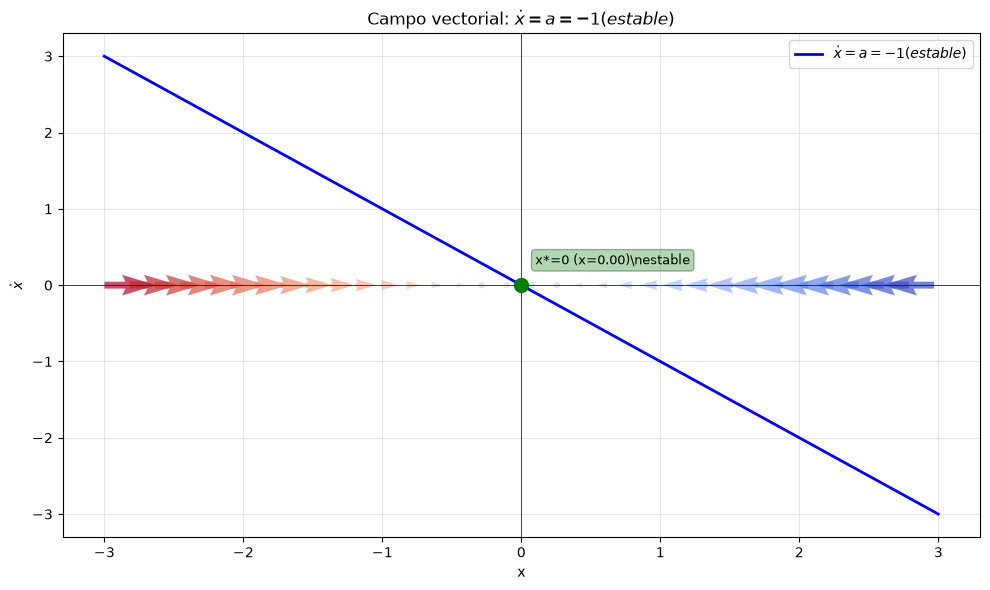

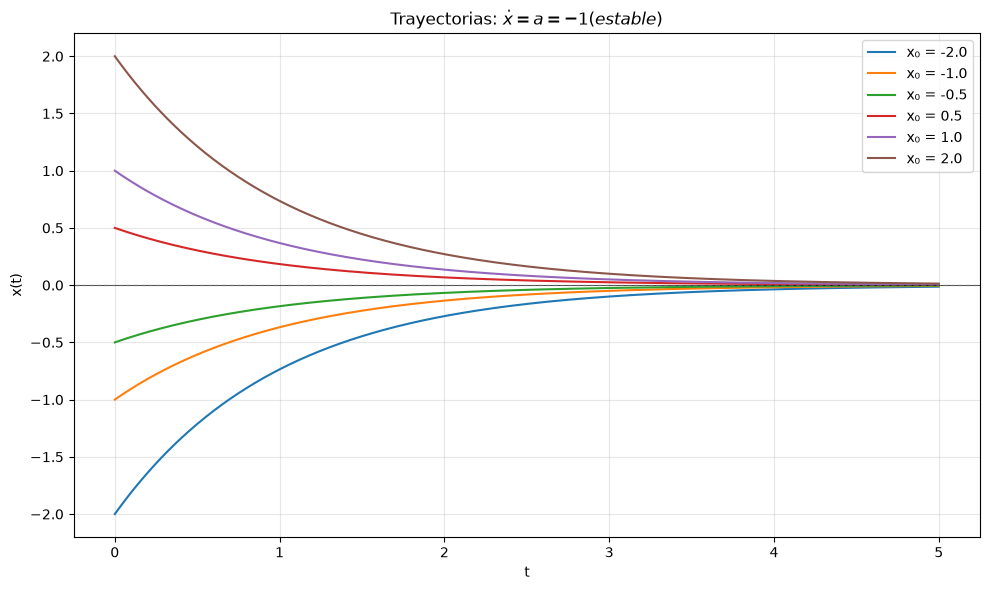

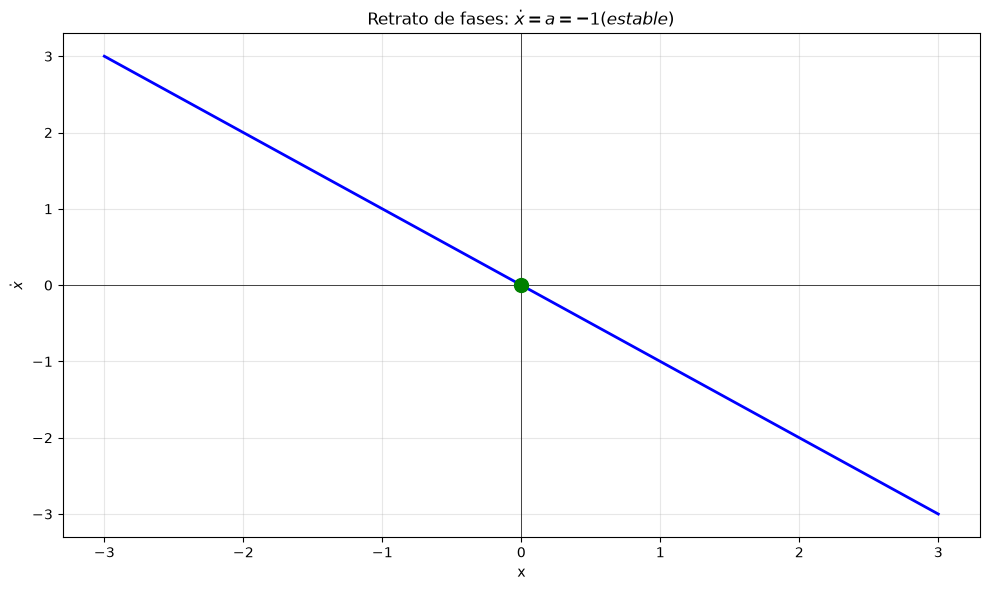


=== a = 1 (inestable) ===
Solución analítica: x(t) = x₀ · e^(at)


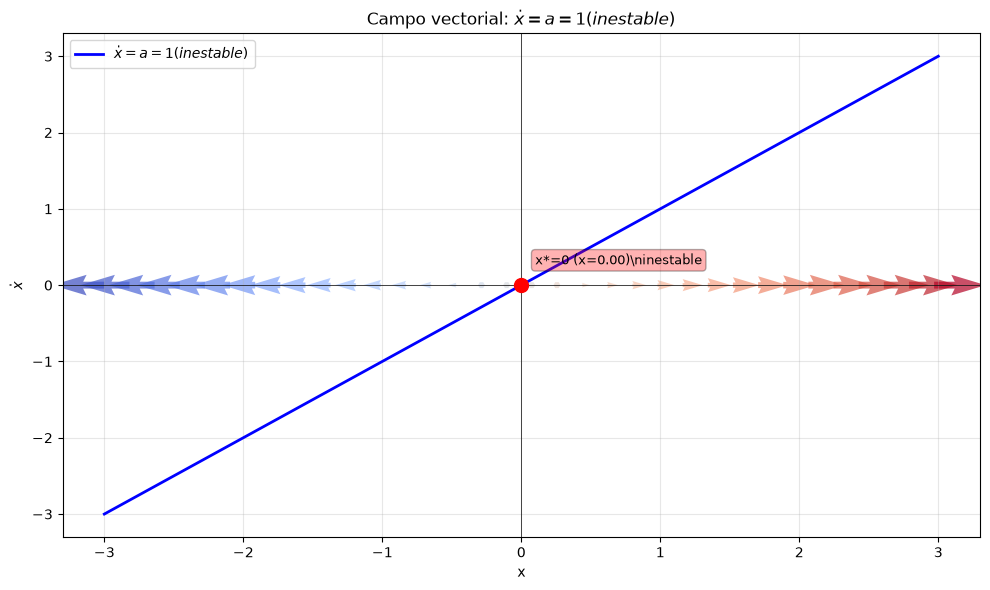

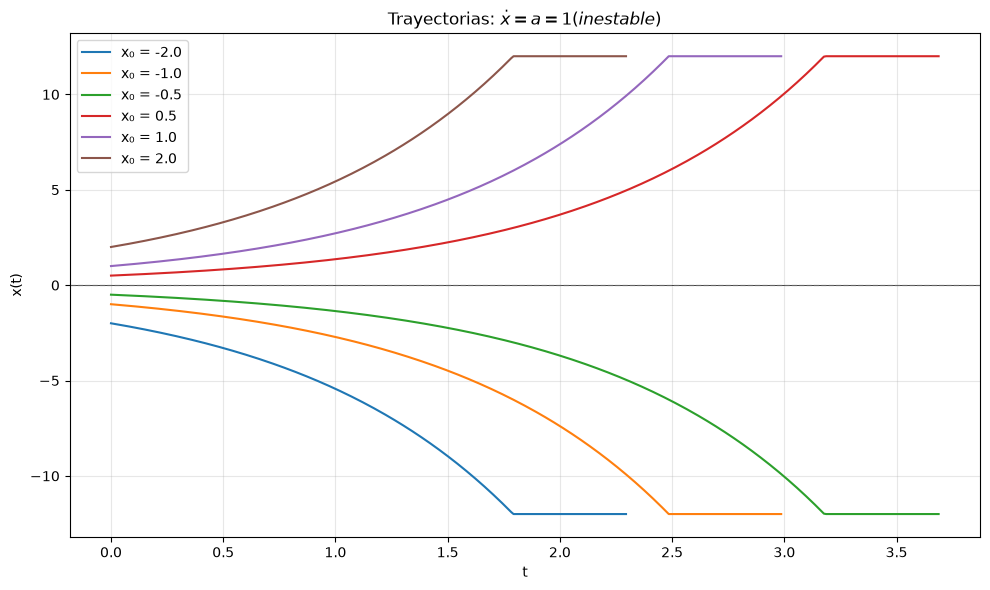

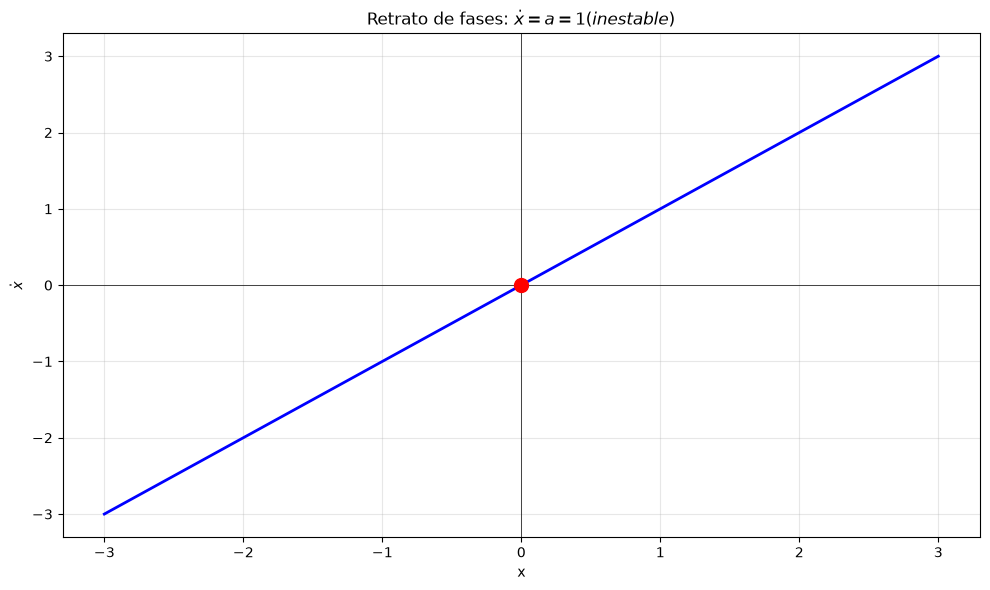

In [3]:
# Probamos con a = 1 (inestable) y a = -1 (estable)
for a_val, a_label in [(-1, 'a = -1 (estable)'), (1, 'a = 1 (inestable)')]:
    f_a = lambda x, a=a_val: a * x
    print(f'\n=== {a_label} ===')
    print(f'Solución analítica: x(t) = x₀ · e^(at)')
    plot_vector_field_and_trajectories(
        f_a, a_label,
        x_range=(-3, 3),
        x0_values=[-2, -1, -0.5, 0.5, 1, 2],
        fixed_points=[(0, 'x*=0')],
        t_span=(0, 5)
    )

---
## (b) $\dot{x} = 4x^2 - 16$

**Análisis:** Puntos fijos en $x^* = \pm 2$. $f'(x) = 8x$, entonces $f'(-2) = -16 < 0$ (estable) y $f'(2) = 16 > 0$ (inestable).

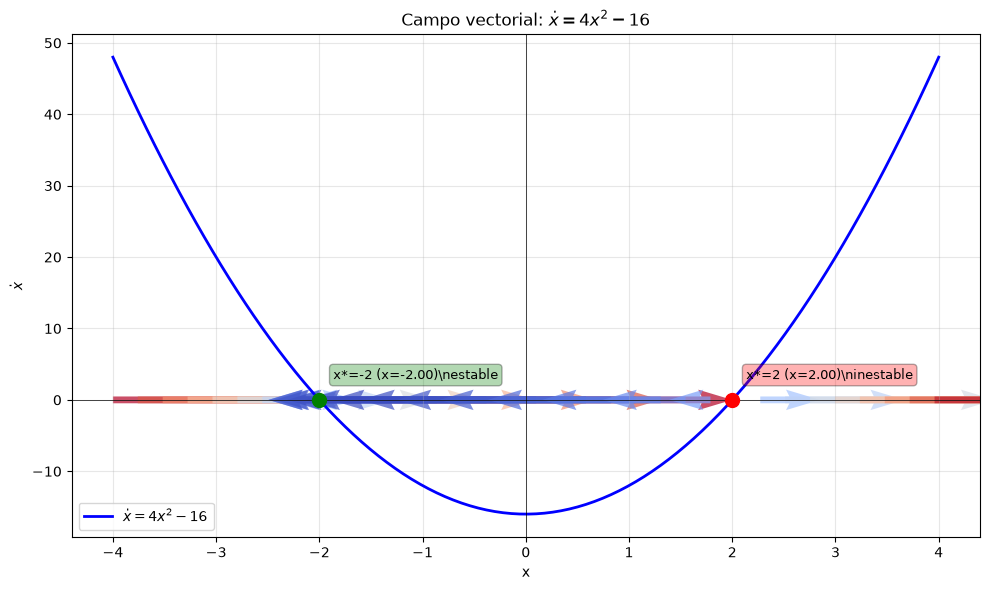

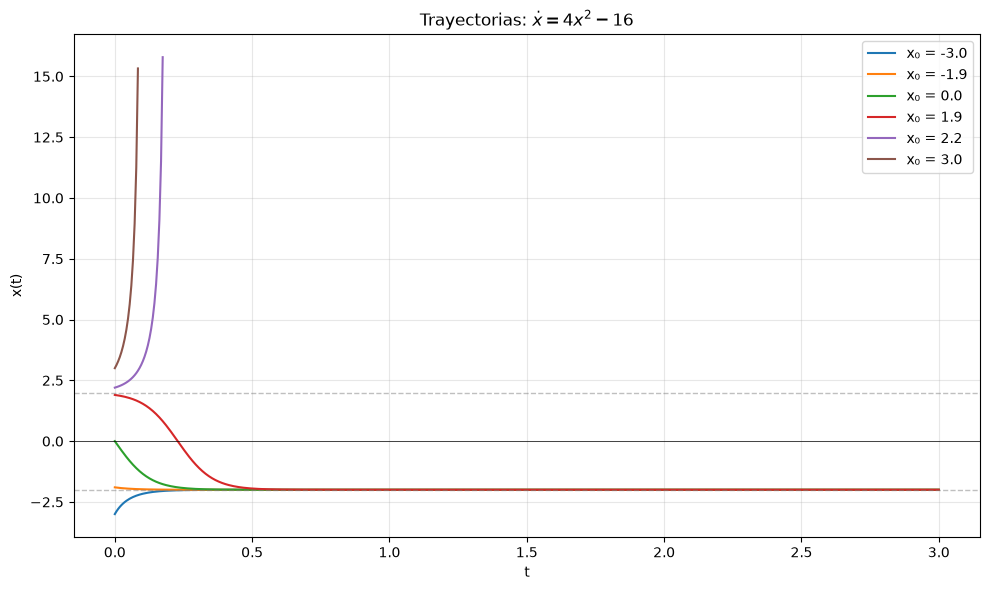

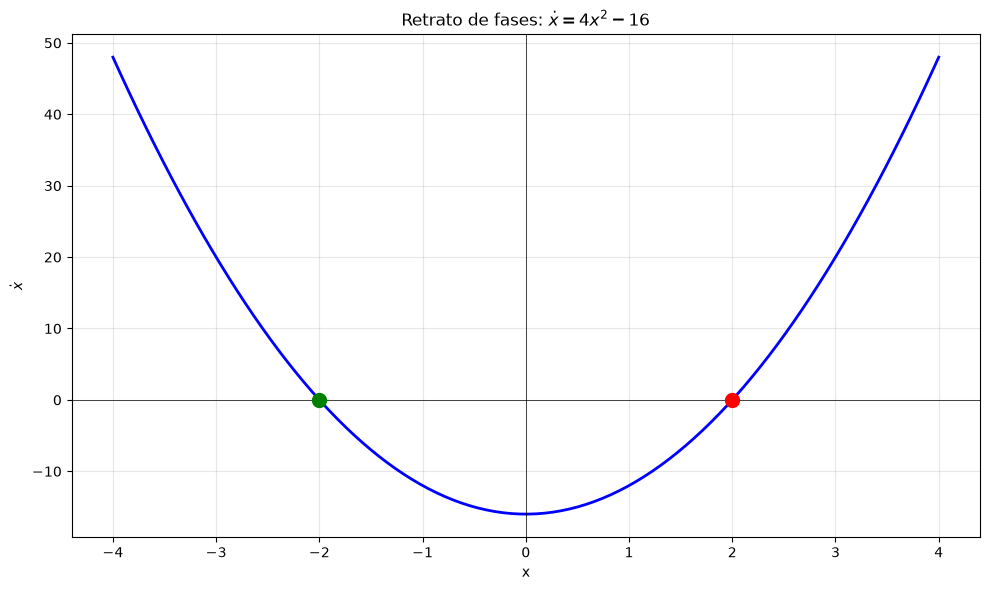

In [4]:
f_b = lambda x: 4 * x**2 - 16
# Una trayectoria representativa de cada 'cuenca' de condiciones iniciales:
#   x0 < -2   : atraídas hacia x*=-2 desde abajo
#   -2<x0<2   : atraídas hacia x*=-2 desde arriba
#   x0 > 2    : x*=2 es inestable -> escapan a +infinito en tiempo FINITO
plot_vector_field_and_trajectories(
    f_b, '4x^2 - 16',
    x_range=(-4, 4),
    x0_values=[-3, -1.9, 0, 1.9, 2.2, 3],
    fixed_points=[(-2, 'x*=-2'), (2, 'x*=2')],
    t_span=(0, 3)
)

### ¿Por qué el signo de $f'(x^*)$ decide la estabilidad? (caso b)

Sea $\delta = x - x^*$ la "perturbación" con respecto al punto fijo. Si arrancamos **cerca** de $x^*$, entonces $x = x^* + \delta$ con $\delta$ pequeño, y por Taylor:

$$\dot{\delta} = \dot{x} = f(x^* + \delta) \approx \underbrace{f(x^*)}_{=0} + f'(x^*)\,\delta = f'(x^*)\,\delta$$

Quedó una ecuación **lineal cuya solución es** $\delta(t) = \delta_0\, e^{f'(x^*)\, t}$.

- Si $f'(x^*) < 0$ → la perturbación **decae** → el punto atrae → **estable**.
- Si $f'(x^*) > 0$ → la perturbación **crece** → el punto repele → **inestable**.

Para **(b)**, $f(x)=4x^2-16$ y $f'(x)=8x$:

| Punto fijo | $f'(x^*)$ | $\delta(t)$ | Estabilidad |
|---|---|---|---|
| $x^*=2$ | $f'(2)=16>0$ | $\delta_0 e^{16t}$ | **inestable** |
| $x^*=-2$ | $f'(-2)=-16<0$ | $\delta_0 e^{-16t}$ | **estable** |

**Lectura gráfica directa (sin cuentas):** $f'(x^*)$ es la *pendiente* con la que la curva $\dot{x}=f(x)$ cruza el eje $\dot{x}=0$ (en un punto fijo la curva pasa por cero).

- **Pendiente negativa** (cruza de $\dot{x}>0$ a $\dot{x}<0$): a la izquierda de $x^*$ el flujo es hacia la derecha (→, se acerca) y a la derecha es hacia la izquierda (←, se acerca). Las flechas **entran** a $x^*$ → **estable**. Es lo que ocurre en $x^*=-2$.
- **Pendiente positiva** (cruza de $\dot{x}<0$ a $\dot{x}>0$): a la izquierda el flujo va a la izquierda (←, se aleja) y a la derecha va a la derecha (→, se aleja). Las flechas **salen** de $x^*$ → **inestable**. Es lo que ocurre en $x^*=2$.

Mirá el campo vectorial de (b): en $x=2$ las flechas divergen y en $x=-2$ convergen.


In [5]:
# Verificación con la linealización: ẋ = f(x) ≈ f'(x*)·δ,  con δ = x - x*
print("Linearización de ẋ = 4x² − 16 cerca de cada punto fijo:\n")
for xstar in [-2.0, 2.0]:
    pendiente = 8 * xstar   # f'(x) = 8x
    tipo = 'inestable' if pendiente > 0 else 'estable'
    print(f"x* = {xstar}: f'(x*) = {pendiente:.0f}  =>  {tipo}")
    print(f"   δ(t) = δ₀ · e^({pendiente:.0f}·t)")

print("\nComprobación numérica: perturbamos cada punto fijo en ±0.001 y vemos si la")
print("distancia a x* crece o se achica después de t=0.3:")
for x0, xstar in [(1.999, 2.0), (2.001, 2.0), (-1.999, -2.0), (-2.001, -2.0)]:
    sol = solve_ivp(lambda t, y: 4*y[0]**2 - 16, (0, 0.3), [x0],
                    t_eval=np.linspace(0, 0.3, 50))
    d0 = abs(x0 - xstar)
    d1 = abs(float(sol.y[0, -1]) - xstar)
    resultado = 'se ESCAPA de x* (inestable)' if d1 > d0 else 'vuelve a x* (estable)'
    print(f"  x0 = {x0:+.3f} (cerca de {xstar:+.0f}): |x-x*| = {d0:.5f} -> {d1:.5f}   => {resultado}")


Linearización de ẋ = 4x² − 16 cerca de cada punto fijo:

x* = -2.0: f'(x*) = -16  =>  estable
   δ(t) = δ₀ · e^(-16·t)
x* = 2.0: f'(x*) = 16  =>  inestable
   δ(t) = δ₀ · e^(16·t)

Comprobación numérica: perturbamos cada punto fijo en ±0.001 y vemos si la
distancia a x* crece o se achica después de t=0.3:
  x0 = +1.999 (cerca de +2): |x-x*| = 0.00100 -> 0.11645   => se ESCAPA de x* (inestable)
  x0 = +2.001 (cerca de +2): |x-x*| = 0.00100 -> 0.12349   => se ESCAPA de x* (inestable)
  x0 = -1.999 (cerca de -2): |x-x*| = 0.00100 -> 0.00005   => vuelve a x* (estable)
  x0 = -2.001 (cerca de -2): |x-x*| = 0.00100 -> 0.00005   => vuelve a x* (estable)


---
## (c) $\dot{x} = x - x^3$

**Análisis:** Puntos fijos en $x^* = 0, \pm 1$. $f'(x) = 1 - 3x^2$, entonces $f'(0) = 1 > 0$ (inestable), $f'(\pm 1) = -2 < 0$ (estables).

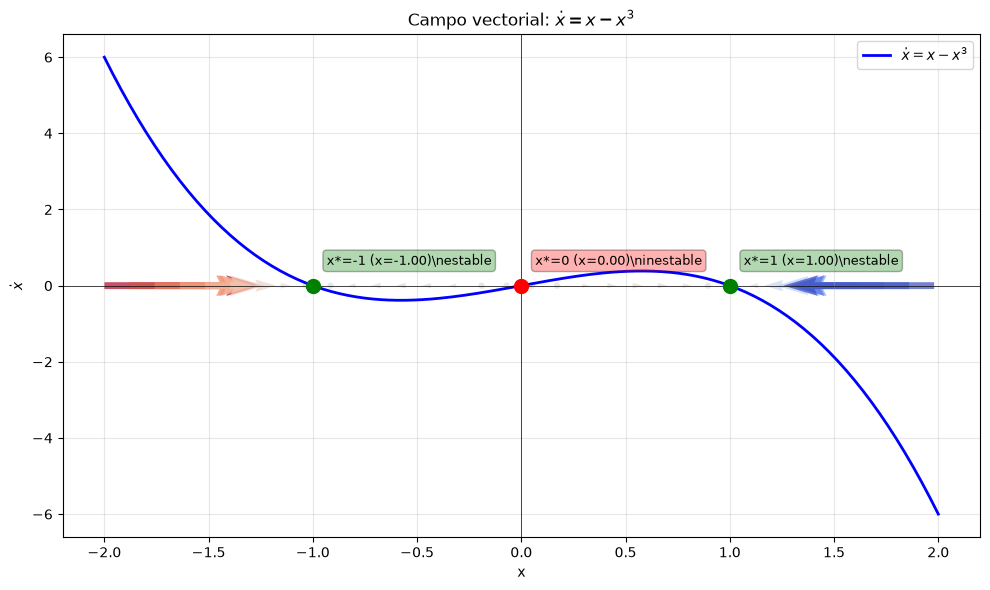

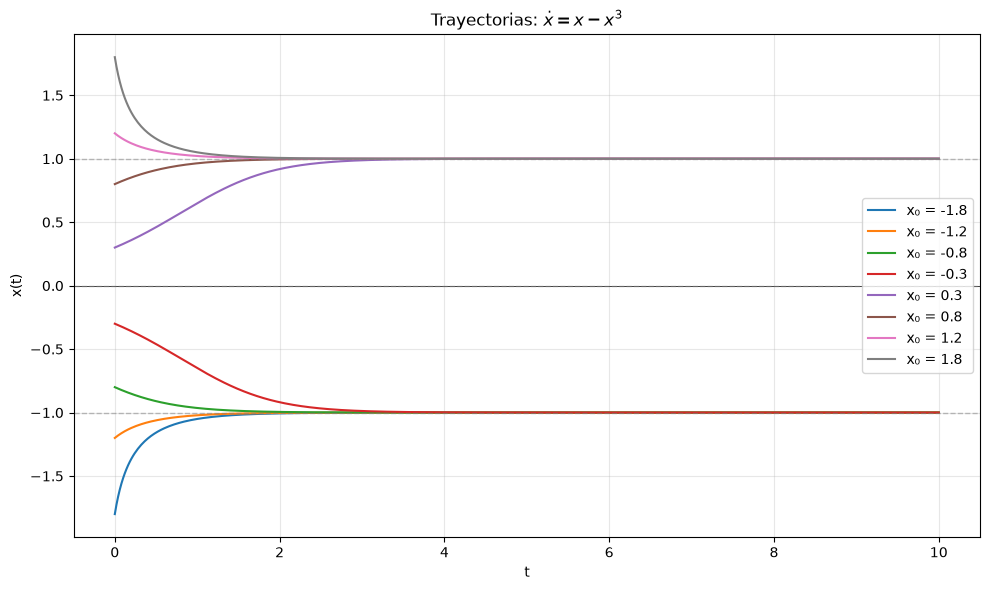

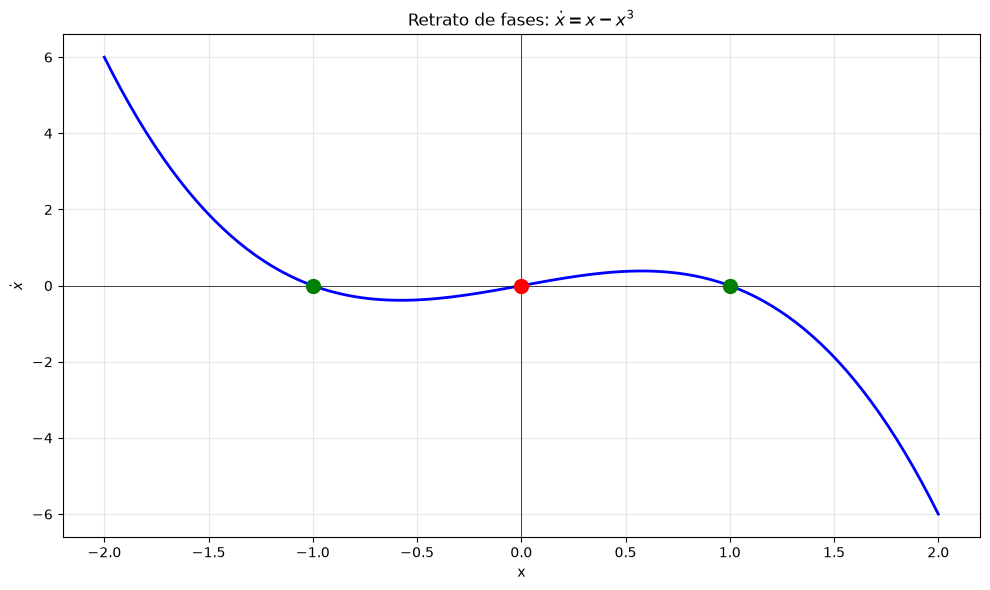

In [6]:
f_c = lambda x: x - x**3
plot_vector_field_and_trajectories(
    f_c, 'x - x^3',
    x_range=(-2, 2),
    x0_values=[-1.8, -1.2, -0.8, -0.3, 0.3, 0.8, 1.2, 1.8],
    fixed_points=[(-1, 'x*=-1'), (0, 'x*=0'), (1, 'x*=1')],
    t_span=(0, 10)
)

---
## (d) $\dot{x} = 1 + 0.5\cos(x)$

**Análisis:** Como $-1 \leq \cos(x) \leq 1$, entonces $0.5 \leq \dot{x} \leq 1.5$. El flujo siempre es positivo: **no hay puntos fijos**. La solución analítica se obtiene por separación de variables:

$$\int \frac{dx}{1 + 0.5\cos(x)} = t + C$$

Esta integral se resuelve con la sustitución $u = \tan(x/2)$ (Weierstrass), pero la expresión resultante es engorrosa.

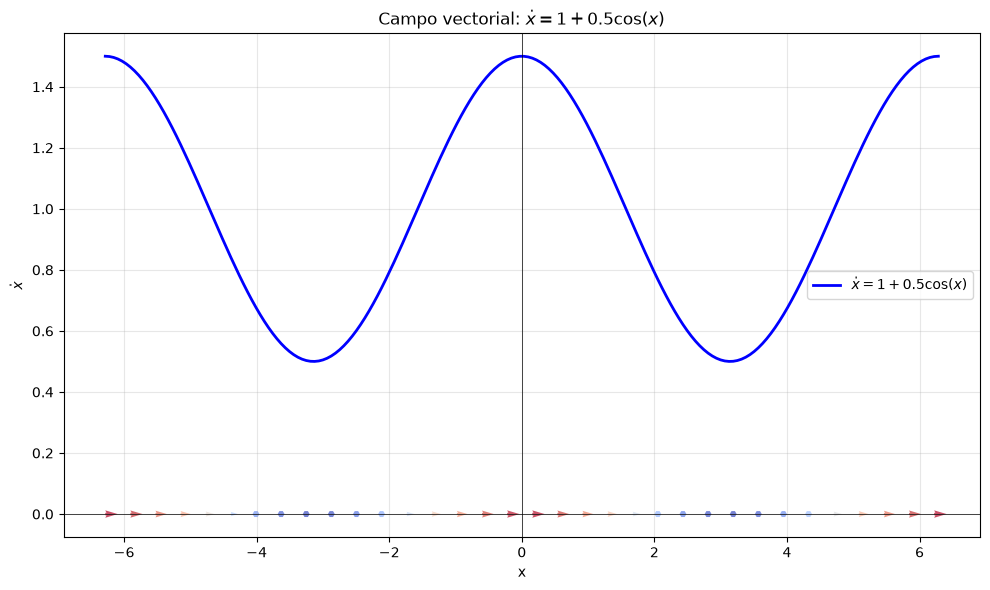

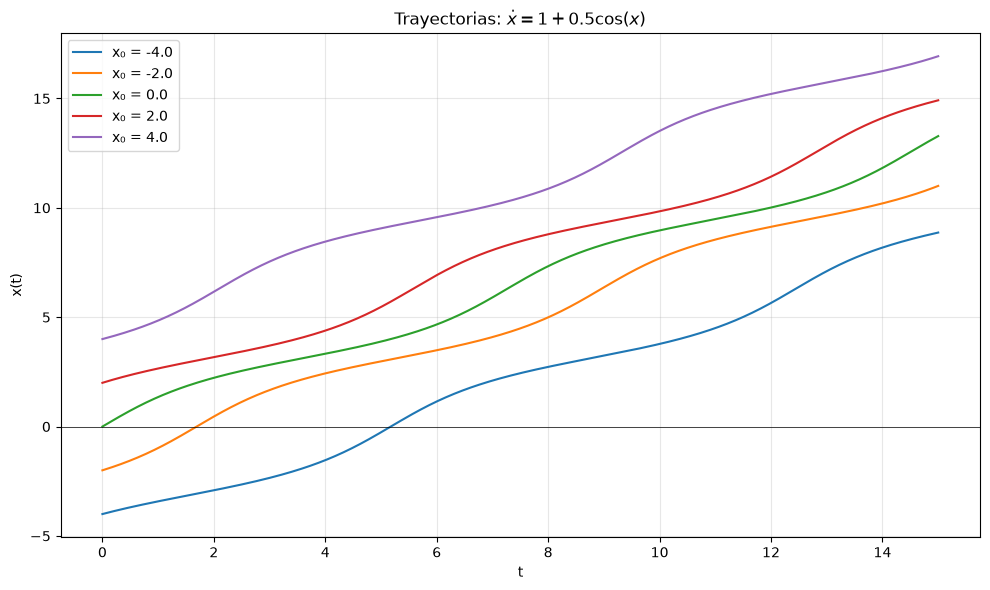

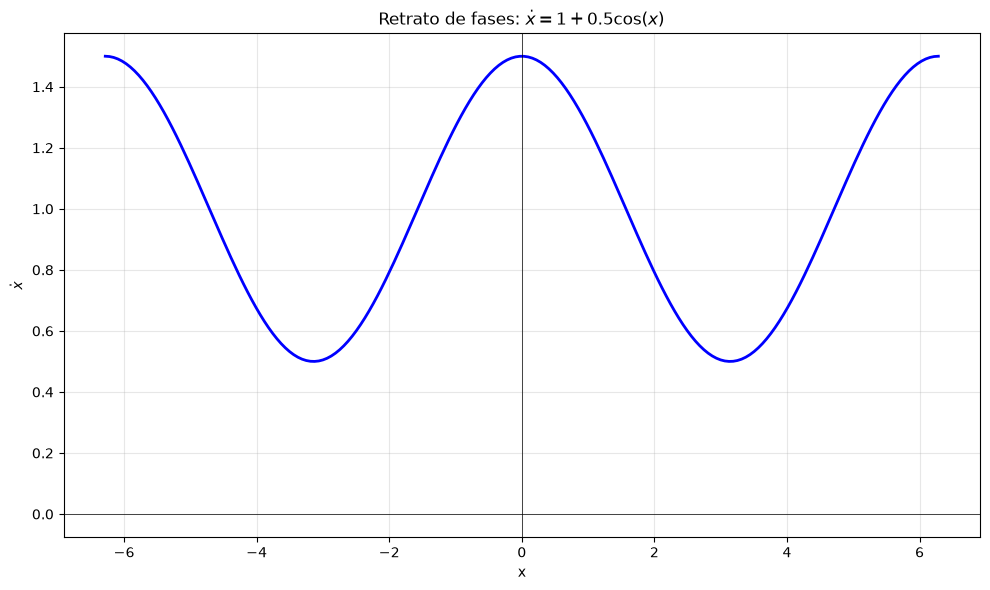

In [7]:
f_d = lambda x: 1 + 0.5 * np.cos(x)
plot_vector_field_and_trajectories(
    f_d, '1 + 0.5\\cos(x)',
    x_range=(-2 * np.pi, 2 * np.pi),
    x0_values=[-4, -2, 0, 2, 4],
    fixed_points=[],
    t_span=(0, 15)
)

---
## (e) $\dot{x} = e^x - \cos(x)$

**Análisis:** Para $x \to +\infty$, $e^x \to \infty$ y la función crece. Para $x \to -\infty$, $e^x \to 0$ y $-\cos(x)$ oscila entre $-1$ y $1$. En $x=0$: $\dot{x} = 1 - 1 = 0$, así que $x^*=0$ es un punto fijo. $f'(x) = e^x + \sin(x)$, $f'(0) = 1 > 0$ (inestable). Puede haber otro punto fijo para $x < 0$ donde $e^x = \cos(x)$.

Punto fijo negativo: x* ≈ -1.2927
Punto fijo en x*=0: f(0) = 0.0000


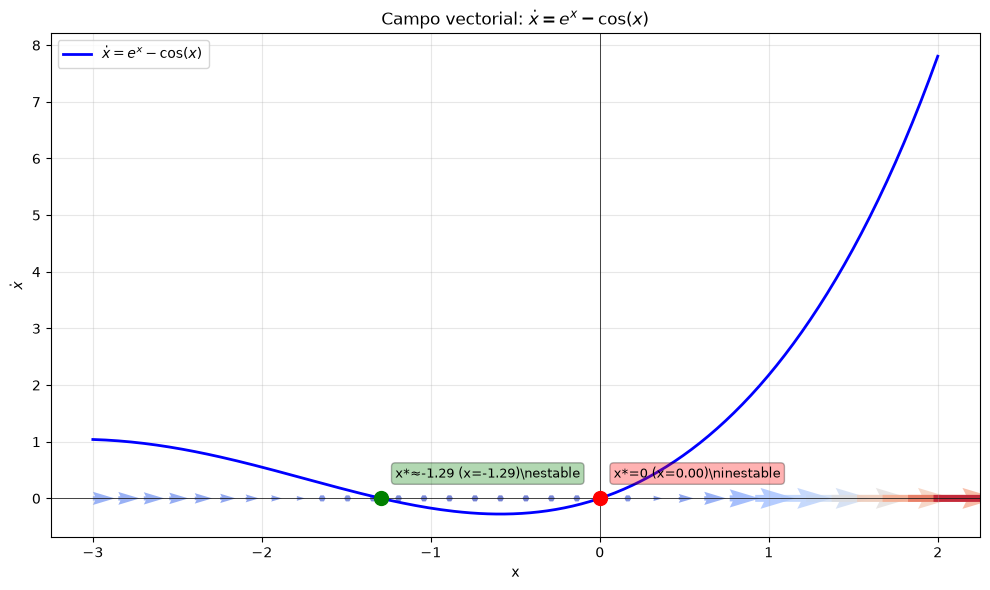

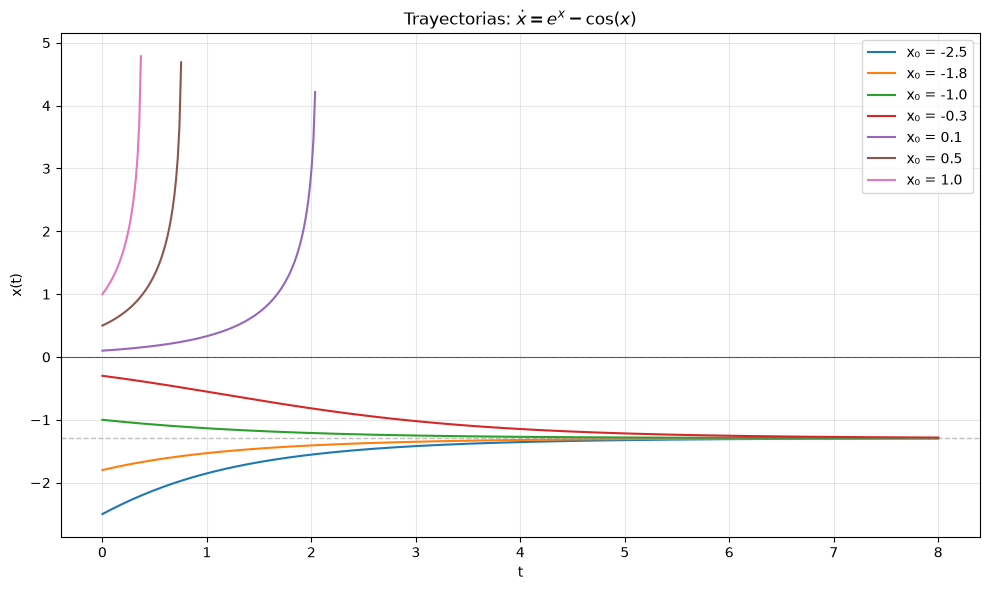

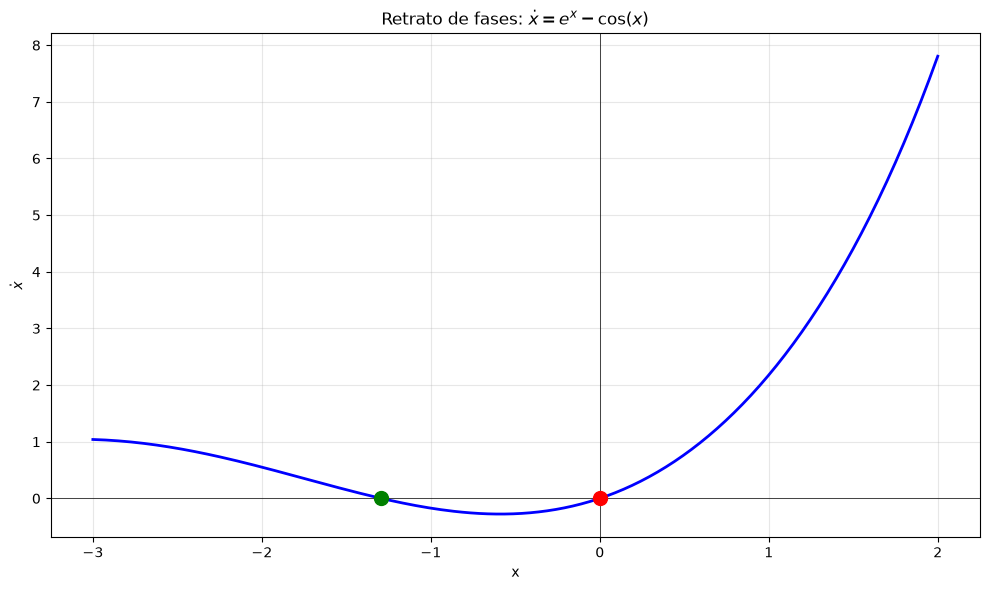

In [8]:
f_e = lambda x: np.exp(x) - np.cos(x)

# Buscamos punto fijo negativo numéricamente
from scipy.optimize import brentq
x_fp_neg = brentq(f_e, -2, -0.5)
print(f'Punto fijo negativo: x* ≈ {x_fp_neg:.4f}')
print(f'Punto fijo en x*=0: f(0) = {f_e(0):.4f}')

plot_vector_field_and_trajectories(
    f_e, 'e^x - \\cos(x)',
    x_range=(-3, 2),
    x0_values=[-2.5, -1.8, -1, -0.3, 0.1, 0.5, 1],
    fixed_points=[(x_fp_neg, f'x*≈{x_fp_neg:.2f}'), (0, 'x*=0')],
    t_span=(0, 8)
)

---
## (f) $\dot{x} = 1 - 2\cos(x)$

**Análisis:** Puntos fijos cuando $\cos(x) = 1/2$, es decir $x^* = \pm \pi/3 + 2k\pi$. $f'(x) = 2\sin(x)$, entonces en $x^* = \pi/3$: $f'(\pi/3) = \sqrt{3} > 0$ (inestable), y en $x^* = -\pi/3$: $f'(-\pi/3) = -\sqrt{3} < 0$ (estable). La solución analítica por separación de variables:

$$\int \frac{dx}{1 - 2\cos(x)} = t + C$$

Usando $u = \tan(x/2)$ se puede resolver.

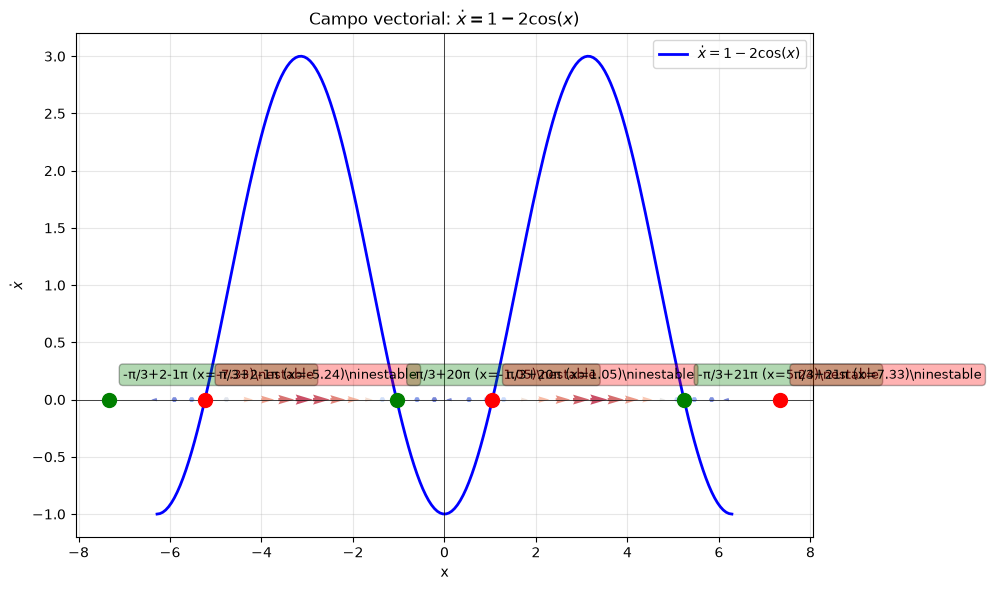

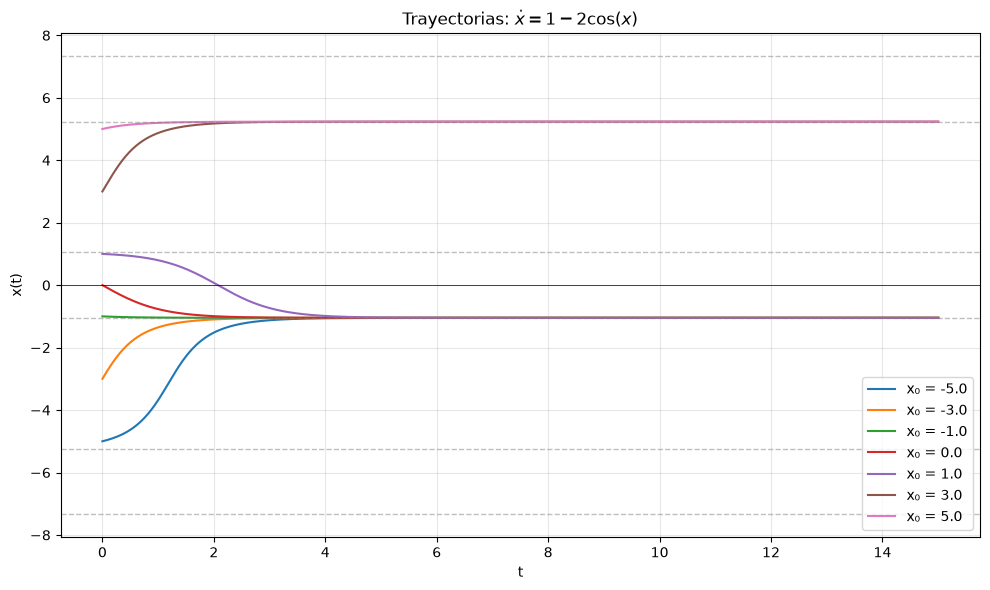

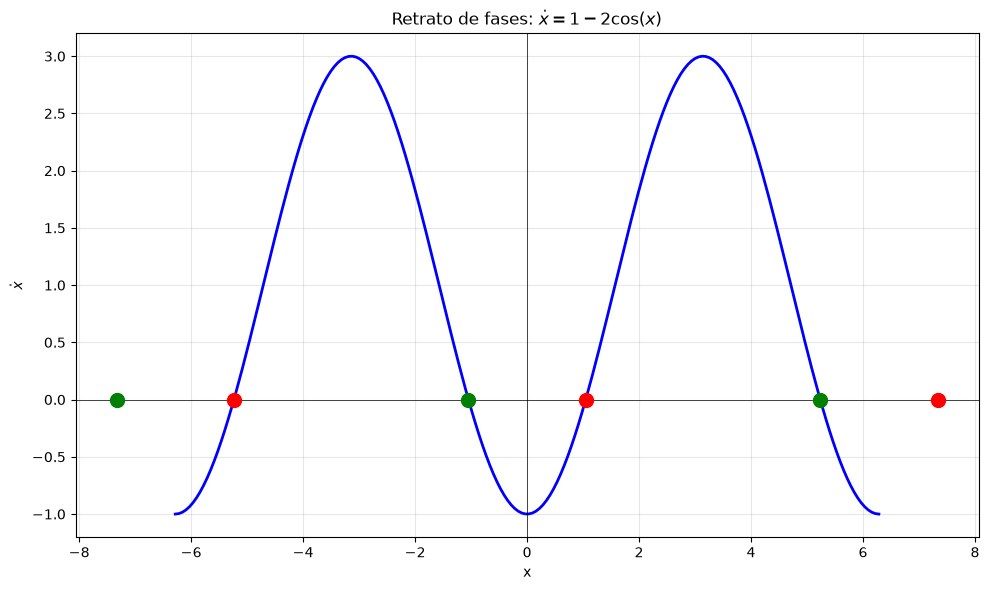

In [9]:
f_f = lambda x: 1 - 2 * np.cos(x)

# Puntos fijos: cos(x) = 1/2 -> x = ±π/3 + 2kπ
fp_list = []
for k in range(-1, 2):
    fp_list.append((np.pi/3 + 2*k*np.pi, f'π/3+2{k}π'))
    fp_list.append((-np.pi/3 + 2*k*np.pi, f'-π/3+2{k}π'))
fp_list.sort(key=lambda t: t[0])

plot_vector_field_and_trajectories(
    f_f, '1 - 2\\cos(x)',
    x_range=(-2 * np.pi, 2 * np.pi),
    x0_values=[-5, -3, -1, 0, 1, 3, 5],
    fixed_points=fp_list,
    t_span=(0, 15)
)

---
## Resumen de estabilidad

| Ecuación | Puntos fijos | Estabilidad |
|----------|-------------|-------------|
| (a) $\dot{x}=ax$ | $x^*=0$ | Estable si $a<0$, inestable si $a>0$ |
| (b) $\dot{x}=4x^2-16$ | $x^*=\pm 2$ | $-2$ estable, $2$ inestable |
| (c) $\dot{x}=x-x^3$ | $x^*=0,\pm 1$ | $0$ inestable, $\pm 1$ estables |
| (d) $\dot{x}=1+0.5\cos x$ | Ninguno | Flujo siempre positivo (regulador) |
| (e) $\dot{x}=e^x-\cos x$ | $x^*\approx -1.3$, $0$ | $-1.3$ estable, $0$ inestable |
| (f) $\dot{x}=1-2\cos x$ | $x^*=\pm\pi/3+2k\pi$ | $-\pi/3+2k\pi$ estable, $\pi/3+2k\pi$ inestable |

En todos los casos, las soluciones o convergen a un punto fijo estable o se alejan de los inestables, confirmando que **las soluciones de sistemas 1D son o atrayentes o repelentes**.